# Assignment 1 - Data and Probability Foundations

## Group Members 

1. Bibek Chaudhary
2. Thomas Psotka
3. Sneha Koirala
4. Samo Susa

## Table of Contents


### Part 1 - Digital Services

#### a. Identify the observational unit, the relevant population, and each variable as categorical or quantitative. Create a frequency table for alert_type containing counts and percentages.


Observational unit:
The observational unit is a single latency measurement recorded for one request handled by one of the three digital services, identified by observational_id.

Relevant Population:
The relevant population is all requests handled by these three digital services over time.

Variable Classification:

1. observation_id: None,
    it is just a row label, not something we can summarize statistically.

2. service: Caterorical
    Because it is a label identifying which of the three services handled the request(e.g: orders). We compare counts/groups, not average.

3. latency_ms: Quantitative
    Because it's a numeric measurement in milliseconds: mean, median, standard deviation, and quartiles are allmeaningful for it.

4. alert_type: Categorical
    Because its a label describing the type of security alerts raised. Again summarised with counts, not average. 

In [2]:
import pandas as pd
from pathlib import Path
 
DATA = Path("../../DATA")
df_ds = pd.read_csv(DATA / "assignment01_digital_services.csv") 

counts = df_ds["alert_type"].value_counts()
percentages = (counts / counts.sum() * 100 ).round(2)

freq_table  = pd.DataFrame({"Count": counts, "Percentage": percentages})

freq_table

,Count,Percentage
alert_type,,
none,104,72.22
authentication,25,17.36
rate_limit,9,6.25
injection_signature,6,4.17


Interpretation: Most requests (72.22%) generated no alert. Authentication was the most common alert type (17.36%), followed by rate-limit alerts (6.25%) and injection-signature alerts (4.17%).This means alerts are relatively rare overall in thiis sample, with most traffic recorded as normal.

#### b. For latency_ms, report the sample size, mean, median, sample standard deviation, minimum, Q1,Q3, maximum, and IQR:
     for all observations combined; and
     separately for each service.

##### For all observations:

In [3]:
import pandas as pd
from pathlib import Path

x = df_ds["latency_ms"]

observations_combined = pd.Series({
    "n": x.size,
    "mean": x.mean(),
    "median": x.median(),
    "std_sample": x.std(ddof=1),
    "min": x.min(),
    "q1": x.quantile(0.25),
    "q3": x.quantile(0.75),
    "max": x.max(),
})

observations_combined["iqr"] = observations_combined["q3"] - observations_combined["q1"]

observations_combined 

n             144.000000
mean          110.111181
median        106.930000
std_sample     23.099319
min            75.210000
q1             95.845000
q3            116.885000
max           223.800000
iqr            21.040000
dtype: float64

Interpretation: Across all 144 observations combined, typical latency is around 106 -110 ms, with a sample standard deviation  of 23.09 ms and a IQR of 21.04 ms. The mean is somewhat higher than the median , and the maximum value is far above the Q3, which hints at a right-skewed distribution with some unusally high latency values.

##### Separetely for each service

In [4]:
def iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

by_service = (df_ds.groupby("service")["latency_ms"].agg(
                n = "size",
                mean = "mean",
                median = "median",
                std_sample = "std",
                min = "min",
                q1 = lambda x: x.quantile(0.25),
                q3 = lambda x: x.quantile(0.75),
                max = "max",
                iqr = iqr
            )
)
by_service

,n,mean,median,std_sample,min,q1,q3,max,iqr
service,,,,,,,,,
identity,49,96.067755,93.720,16.120889,75.21,85.3900,105.1000,154.27,19.71
orders,50,122.200000,114.525,24.812508,98.53,109.8375,124.1475,223.80,14.31
telemetry,45,111.970889,106.920,19.384678,86.78,97.9500,116.8300,177.87,18.88


Intrepretation: identity is the fastest and most consistent service, with the lowest typical latency and smallest spread. orders has the highest typical latency and largest standard deviation, but its IQR is actually the smallest — meaning most orders requests are tightly clustered, with a few extreme high values pulling the mean and standard deviation upward. telemetry falls in between. Across all three services, the mean exceeds the median, and each maximum sits well above Q3, hinting at right-skewed distributions with some unusually high latency values — a pattern worth flagging rather than overlooking.

#### c. Create a histogram of all latency measurements and side-by-side boxplots for the three services. Explain the histogram's axes, bins, and displayed shape and the boxplot's median, box, whiskers, and plotted potential outliers.

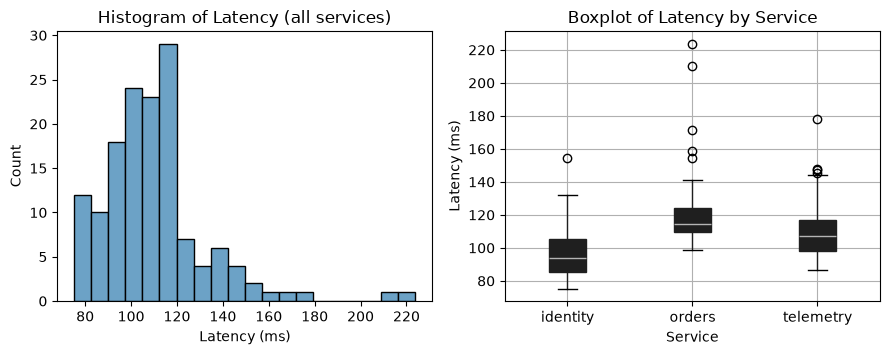

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA = Path("../../DATA")
df_ds = pd.read_csv(DATA / "assignment01_digital_services.csv")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

# Histogram
axes[0].hist(df_ds["latency_ms"], bins=20, edgecolor="black", color="#6CA2C6")
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Latency (all services)")

# Side by side boxplots
df_ds.boxplot(column="latency_ms", by="service", ax=axes[1], patch_artist=True)
axes[1].set_title("Boxplot of Latency by Service")
axes[1].set_xlabel("Service")
axes[1].set_ylabel("Latency (ms)")

plt.suptitle("")
plt.tight_layout()
plt.show()

The histogram groups the 144 combined latency measurements into 20 equal-width bins along the horizontal axis (latency in ms), with the vertical axis showing the count of observations in each bin. The distribution is unimodal, with a main peak around 105–115 ms, and shows clear right skew: most values cluster between 75 and 120 ms, followed by a thinning tail extending past 150 ms, a visible gap around 180–205 ms, and two isolated high values near 210–220 ms.


The boxplots, read from the centre outward, show the median line inside each box, the box spanning Q1 to Q3 (the middle 50% of each service's data), and whiskers extending only to the most extreme observed values still inside the 1.5×IQR fences — not to the true minimum or maximum. Points beyond the whiskers are plotted individually as potential outliers: orders shows the most and most extreme outliers, including the sample's overall maximum near 224 ms, while identity shows only one mild outlier and telemetry shows a small cluster just above its upper whisker.

#### d. Apply the  1.5 * IQR rule within each service. Report the IDs and values of potential outliers, retain them in the analysis, and explain why a plotted outlier is not automatically a data error.

In [8]:
def flag_outliers(group):
    q1 = group["latency_ms"].quantile(0.25)
    q3 = group["latency_ms"].quantile(0.75)
    iqr_val = q3 - q1
    low = q1 - 1.5 * iqr_val
    high = q3 + 1.5 * iqr_val
    mask = (group["latency_ms"] < low) | (group["latency_ms"] > high)

    result = group.loc[mask, ["observation_id", "latency_ms"]].copy()
    result.insert(1, "service", group.name)
    return result

outliers = df_ds.groupby("service", group_keys=False).apply(flag_outliers)
outliers

,observation_id,service,latency_ms
131,132,identity,154.27
18,19,orders,210.10
59,60,orders,171.59
65,66,orders,158.59
86,87,orders,154.32
87,88,orders,223.80
32,33,telemetry,147.26
38,39,telemetry,145.52
119,120,telemetry,147.79
132,133,telemetry,177.87
